# Long-Dependency ARMA Data Generator

This notebook creates synthetic ARMA series with prescribed long-range dependencies (single-lag autoregressive emphasis), and also create random-walk series, white noise series.


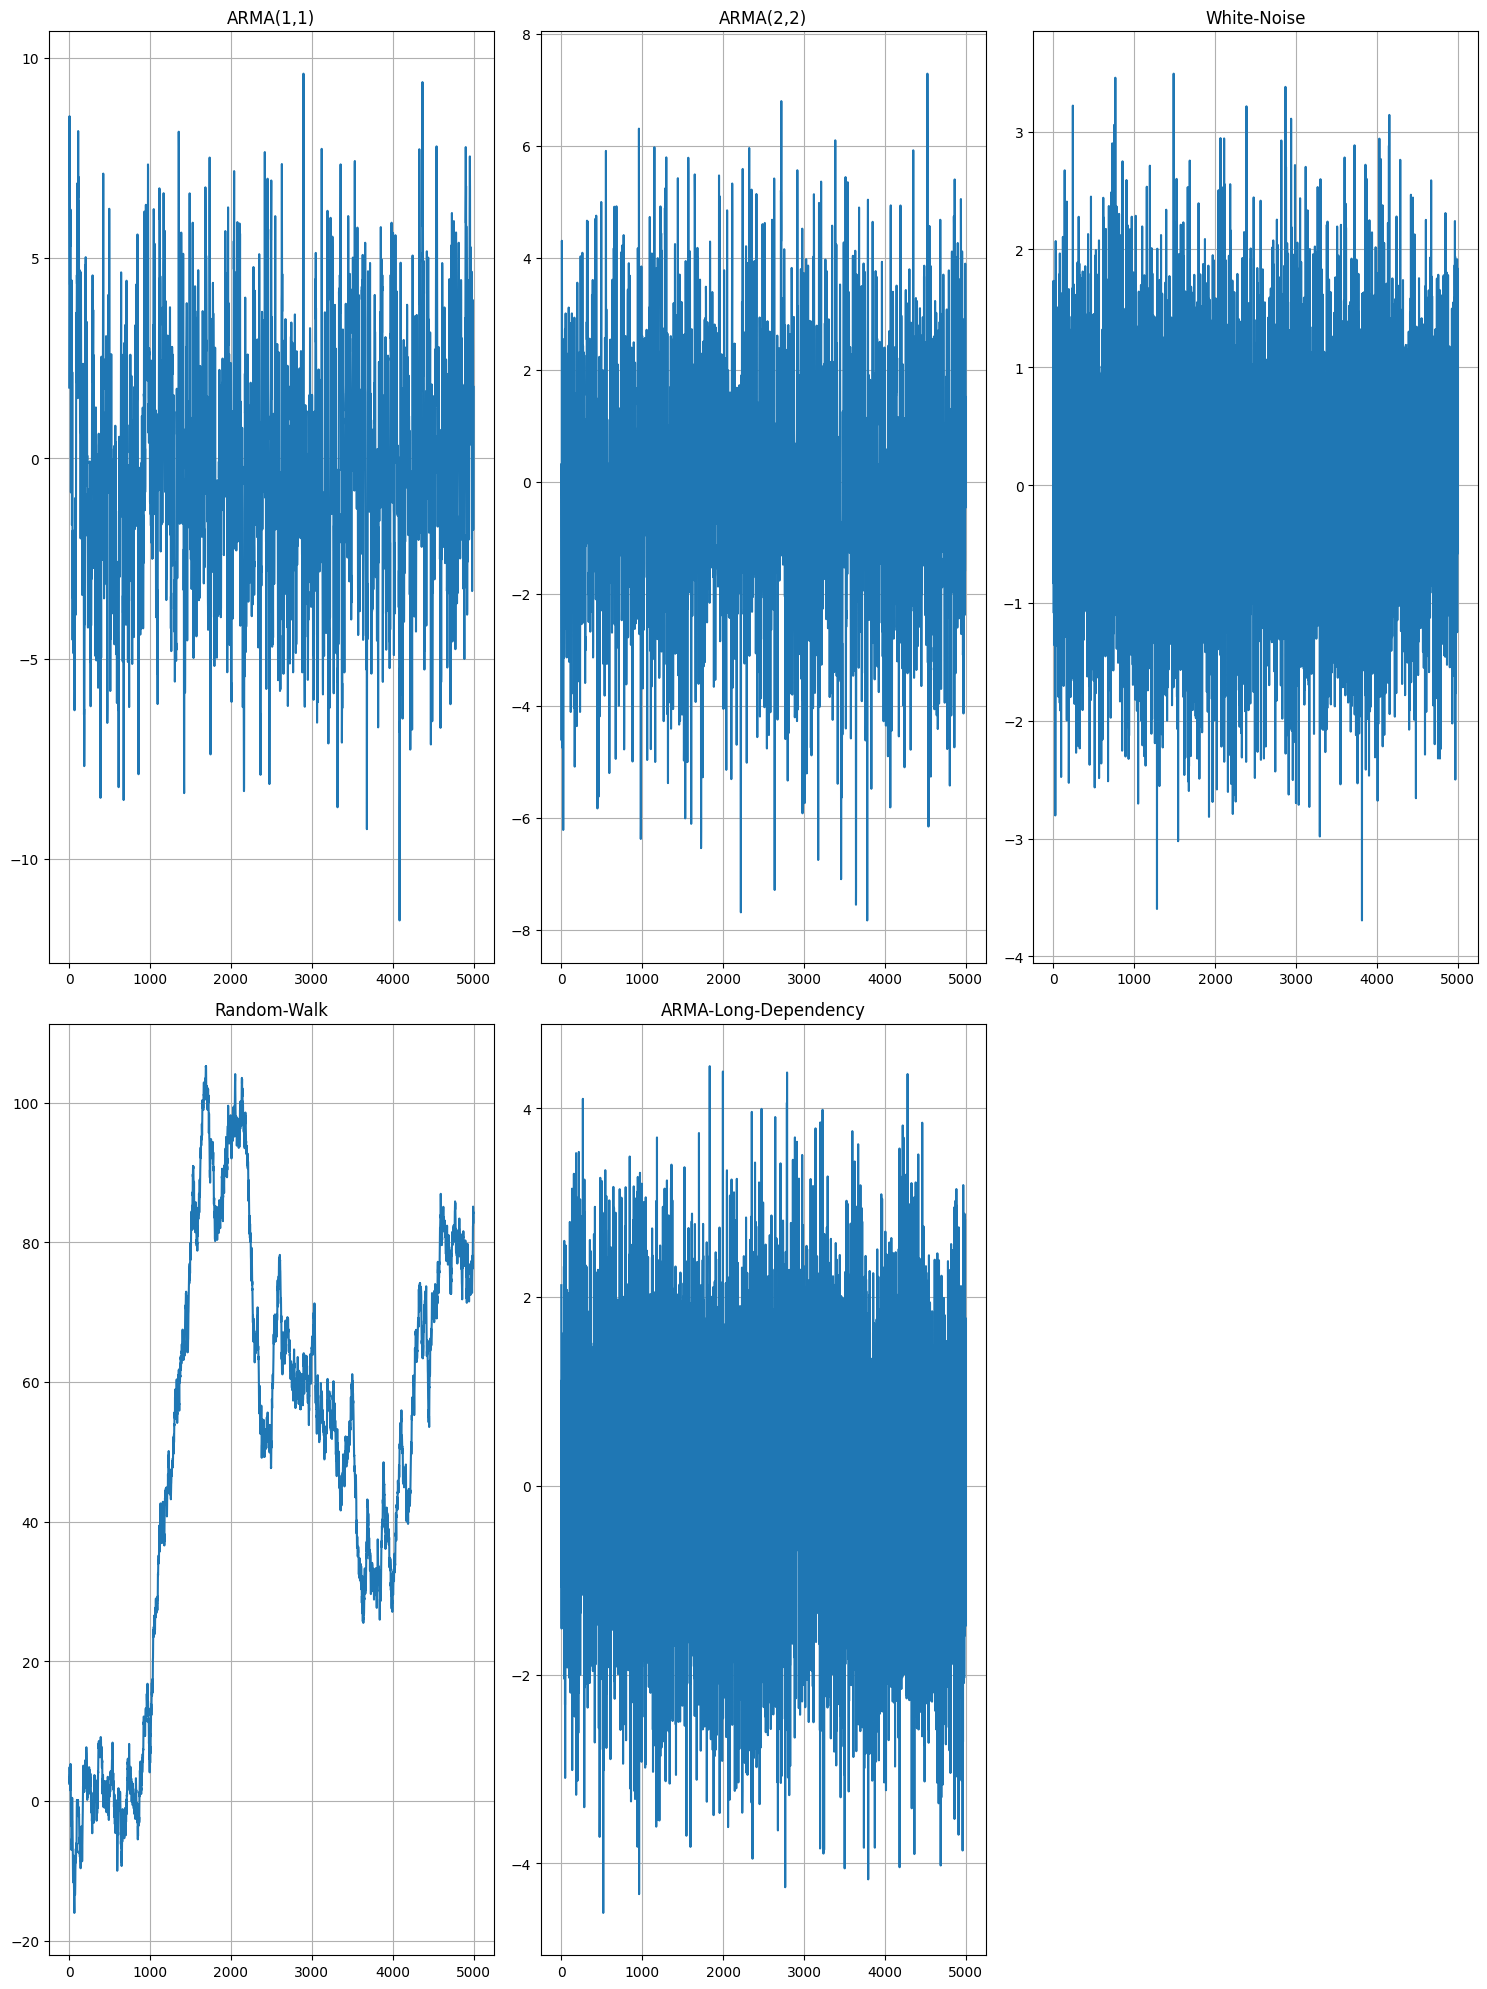

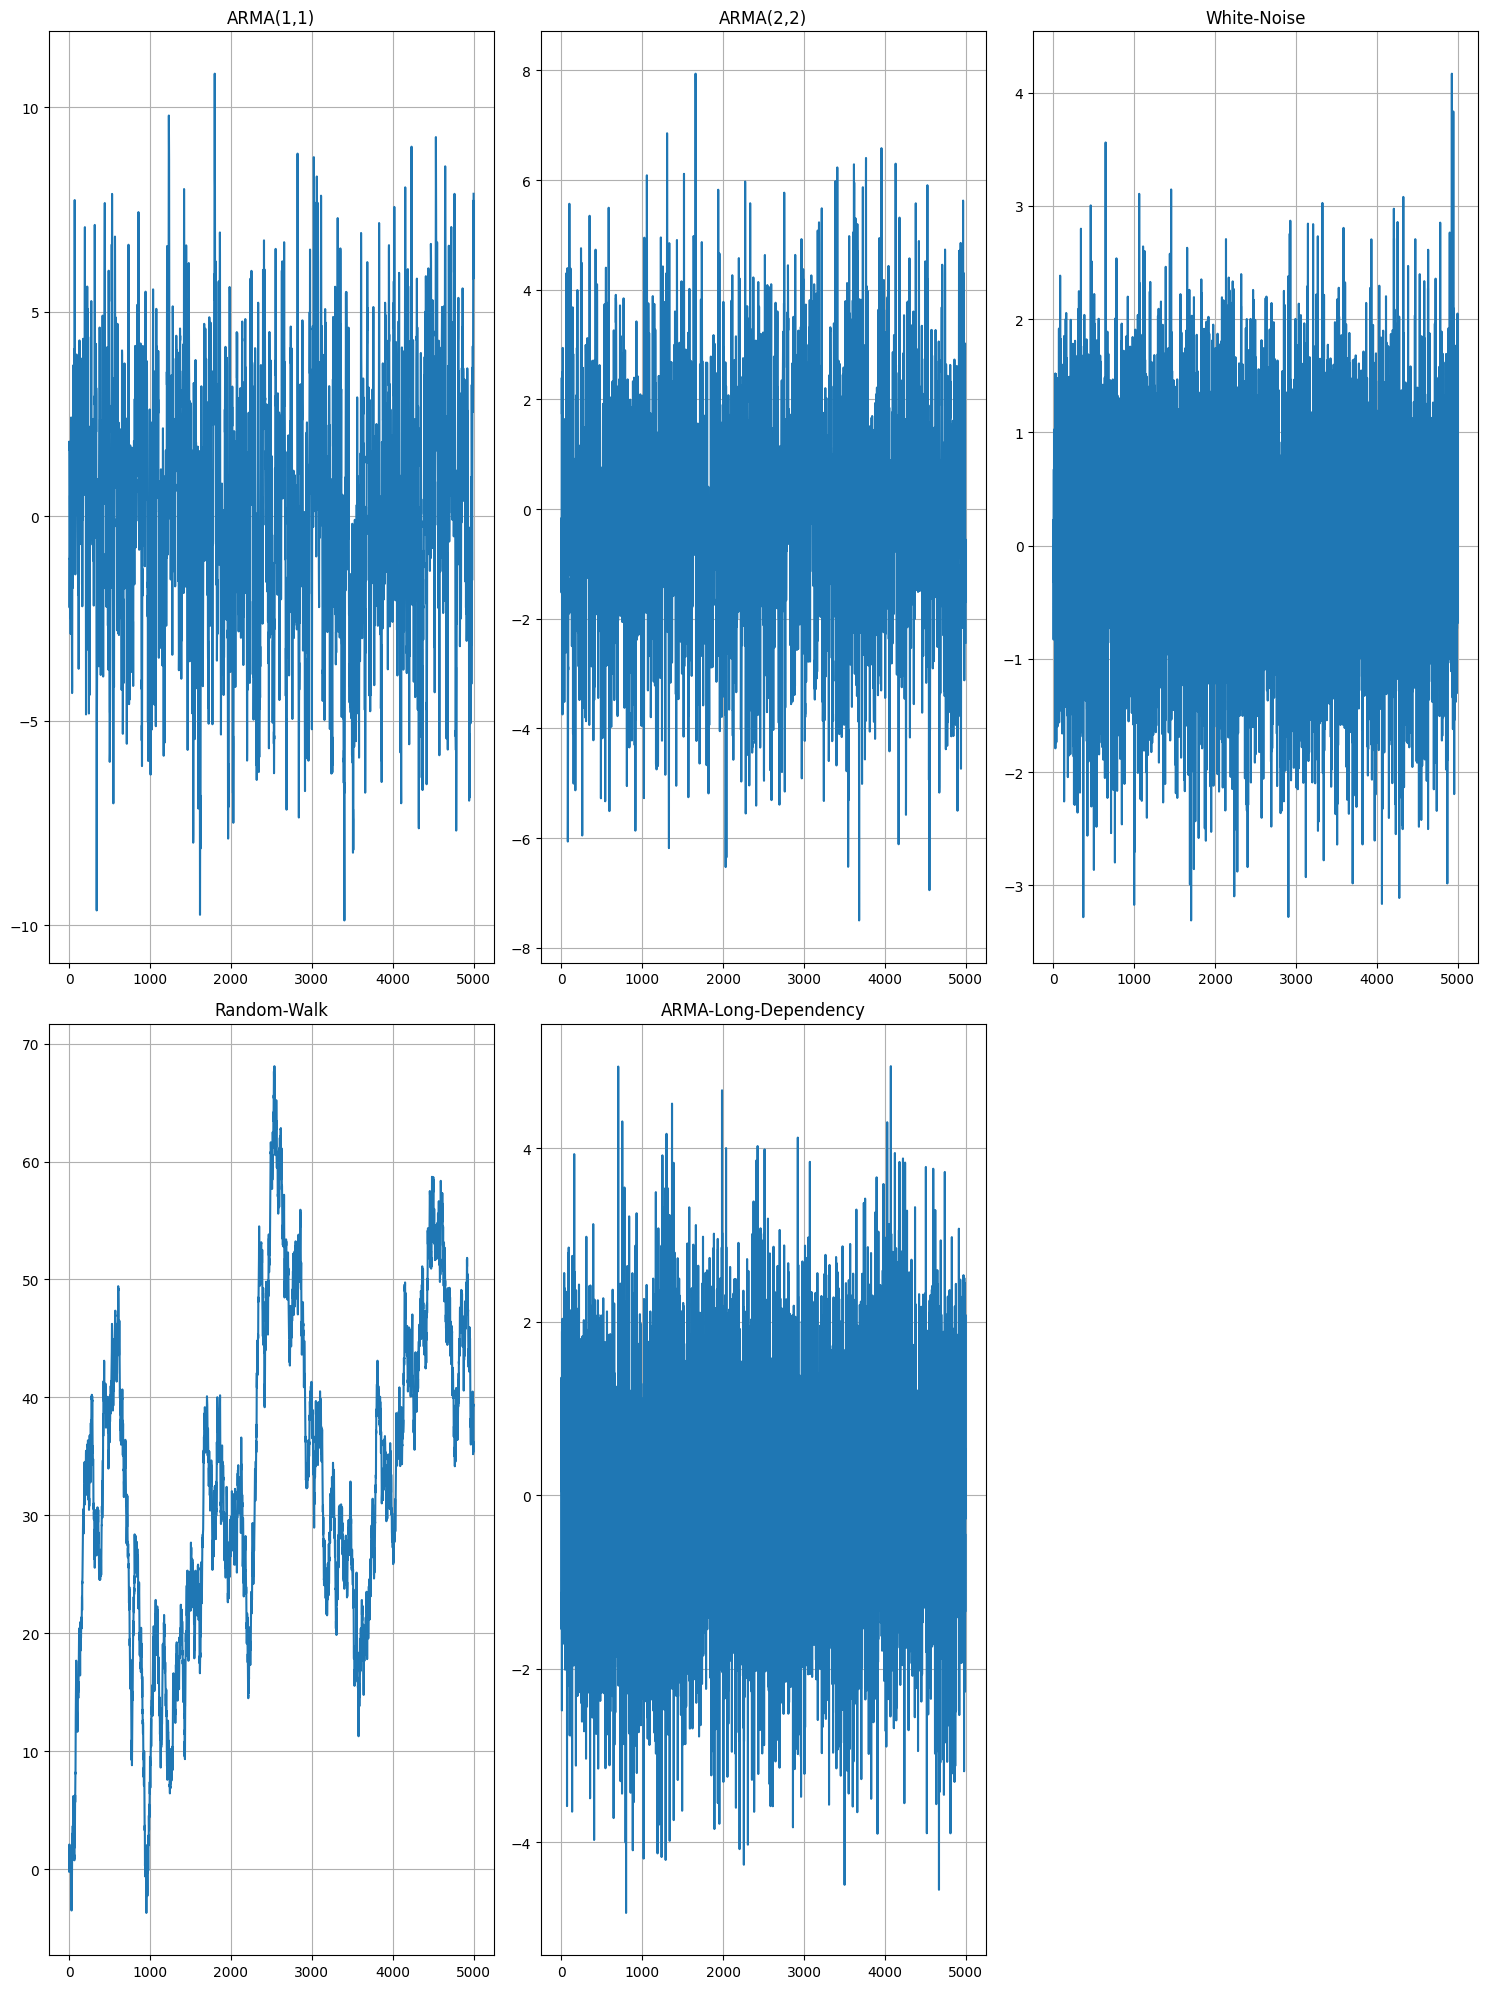

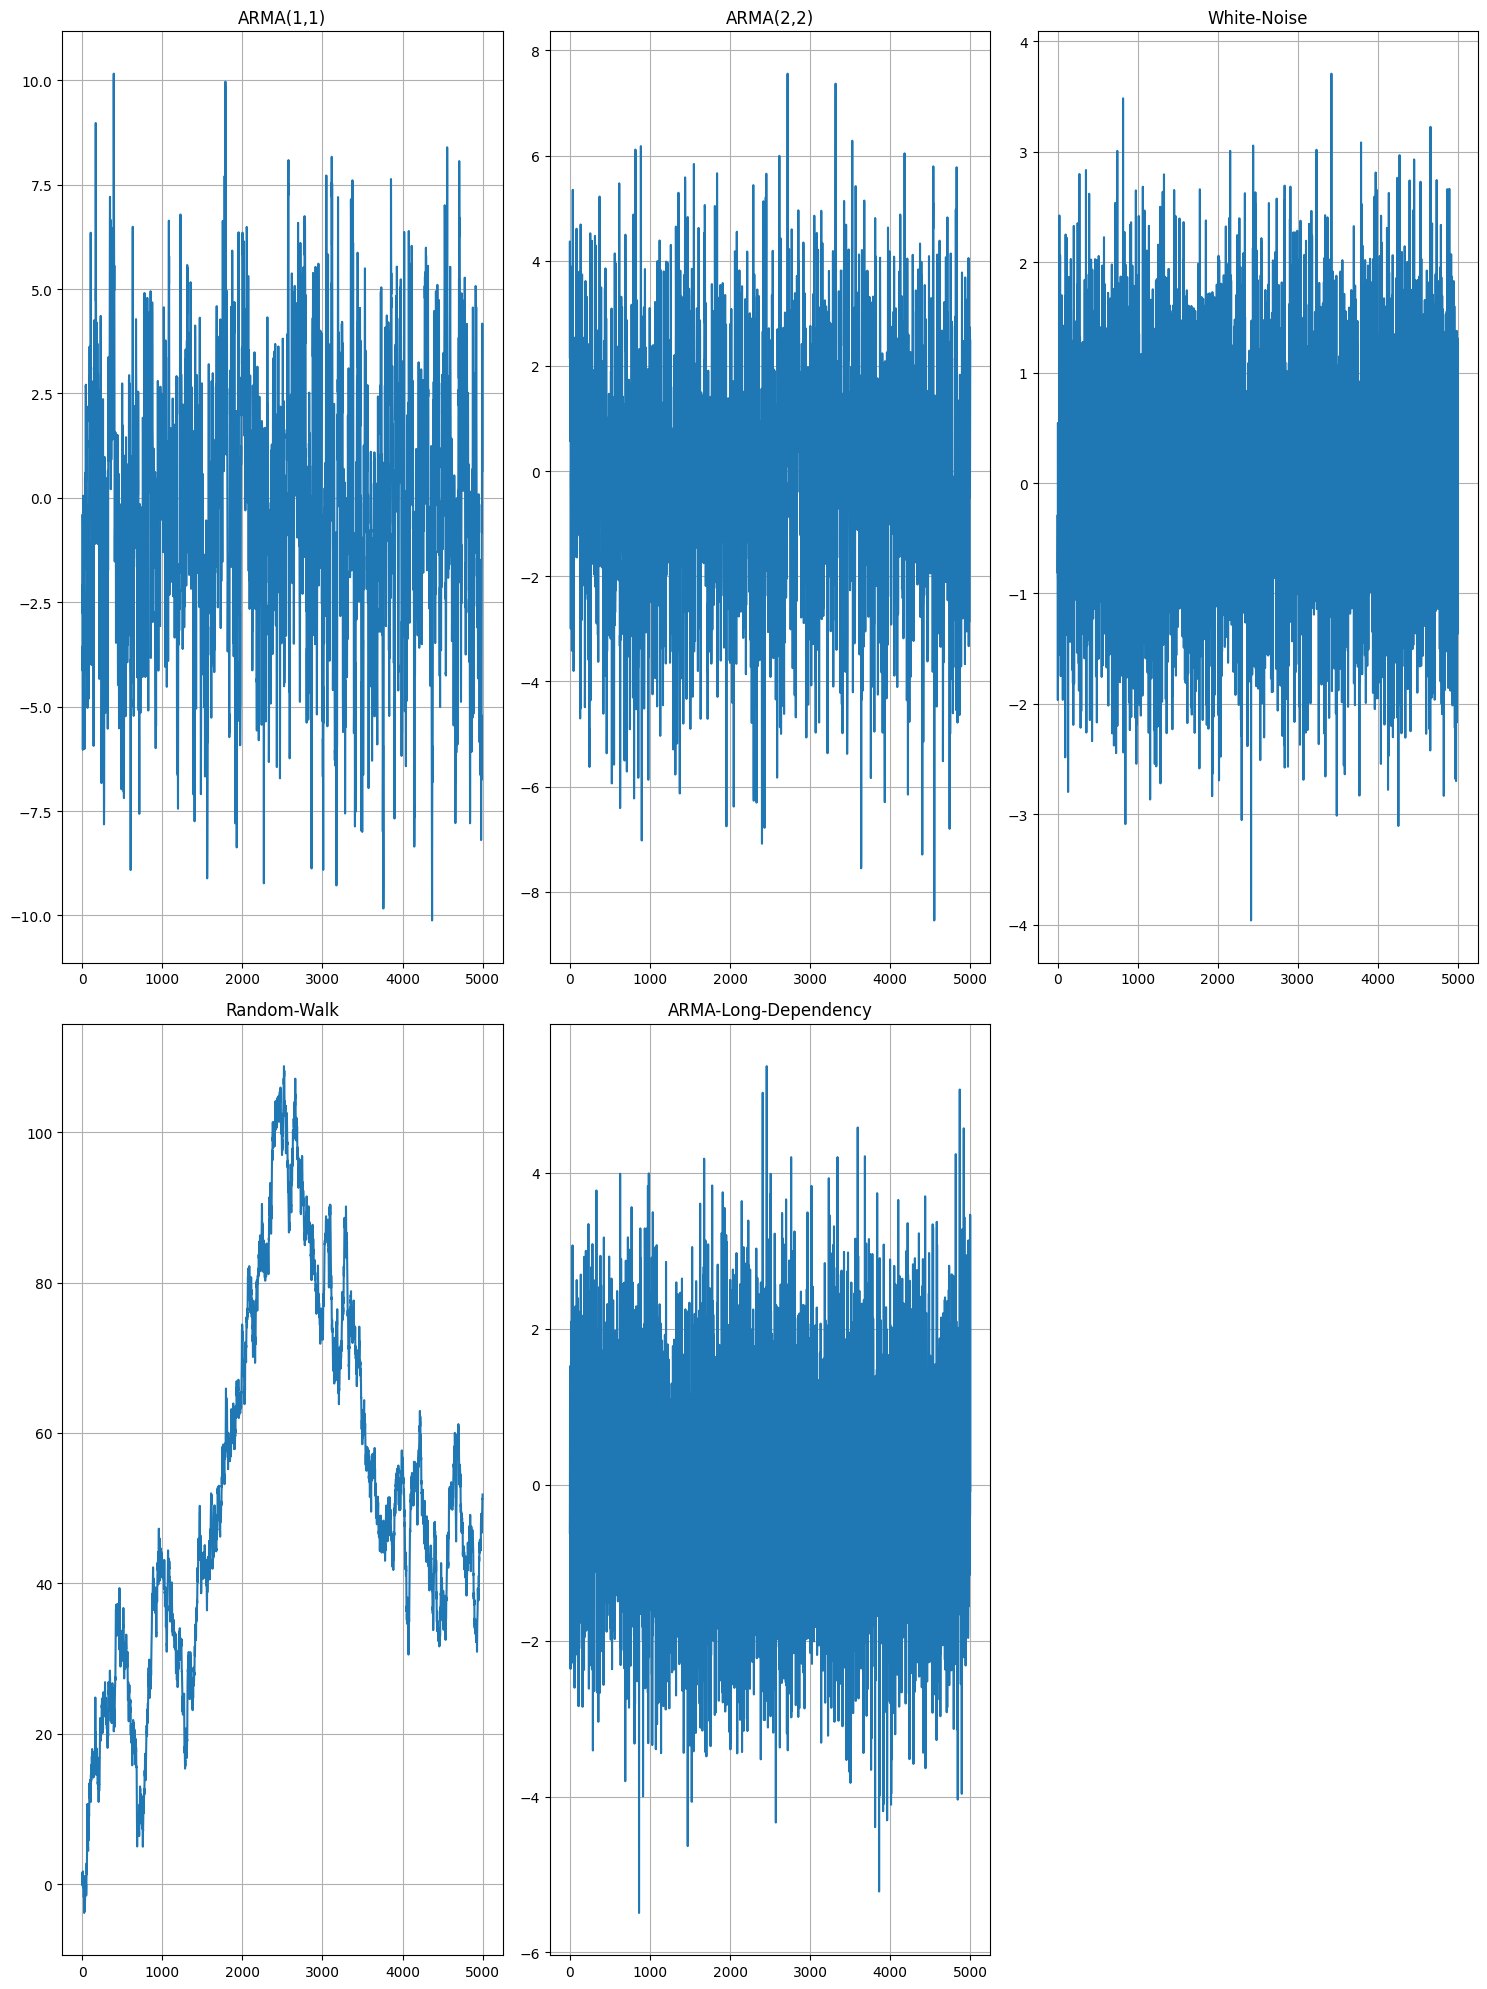

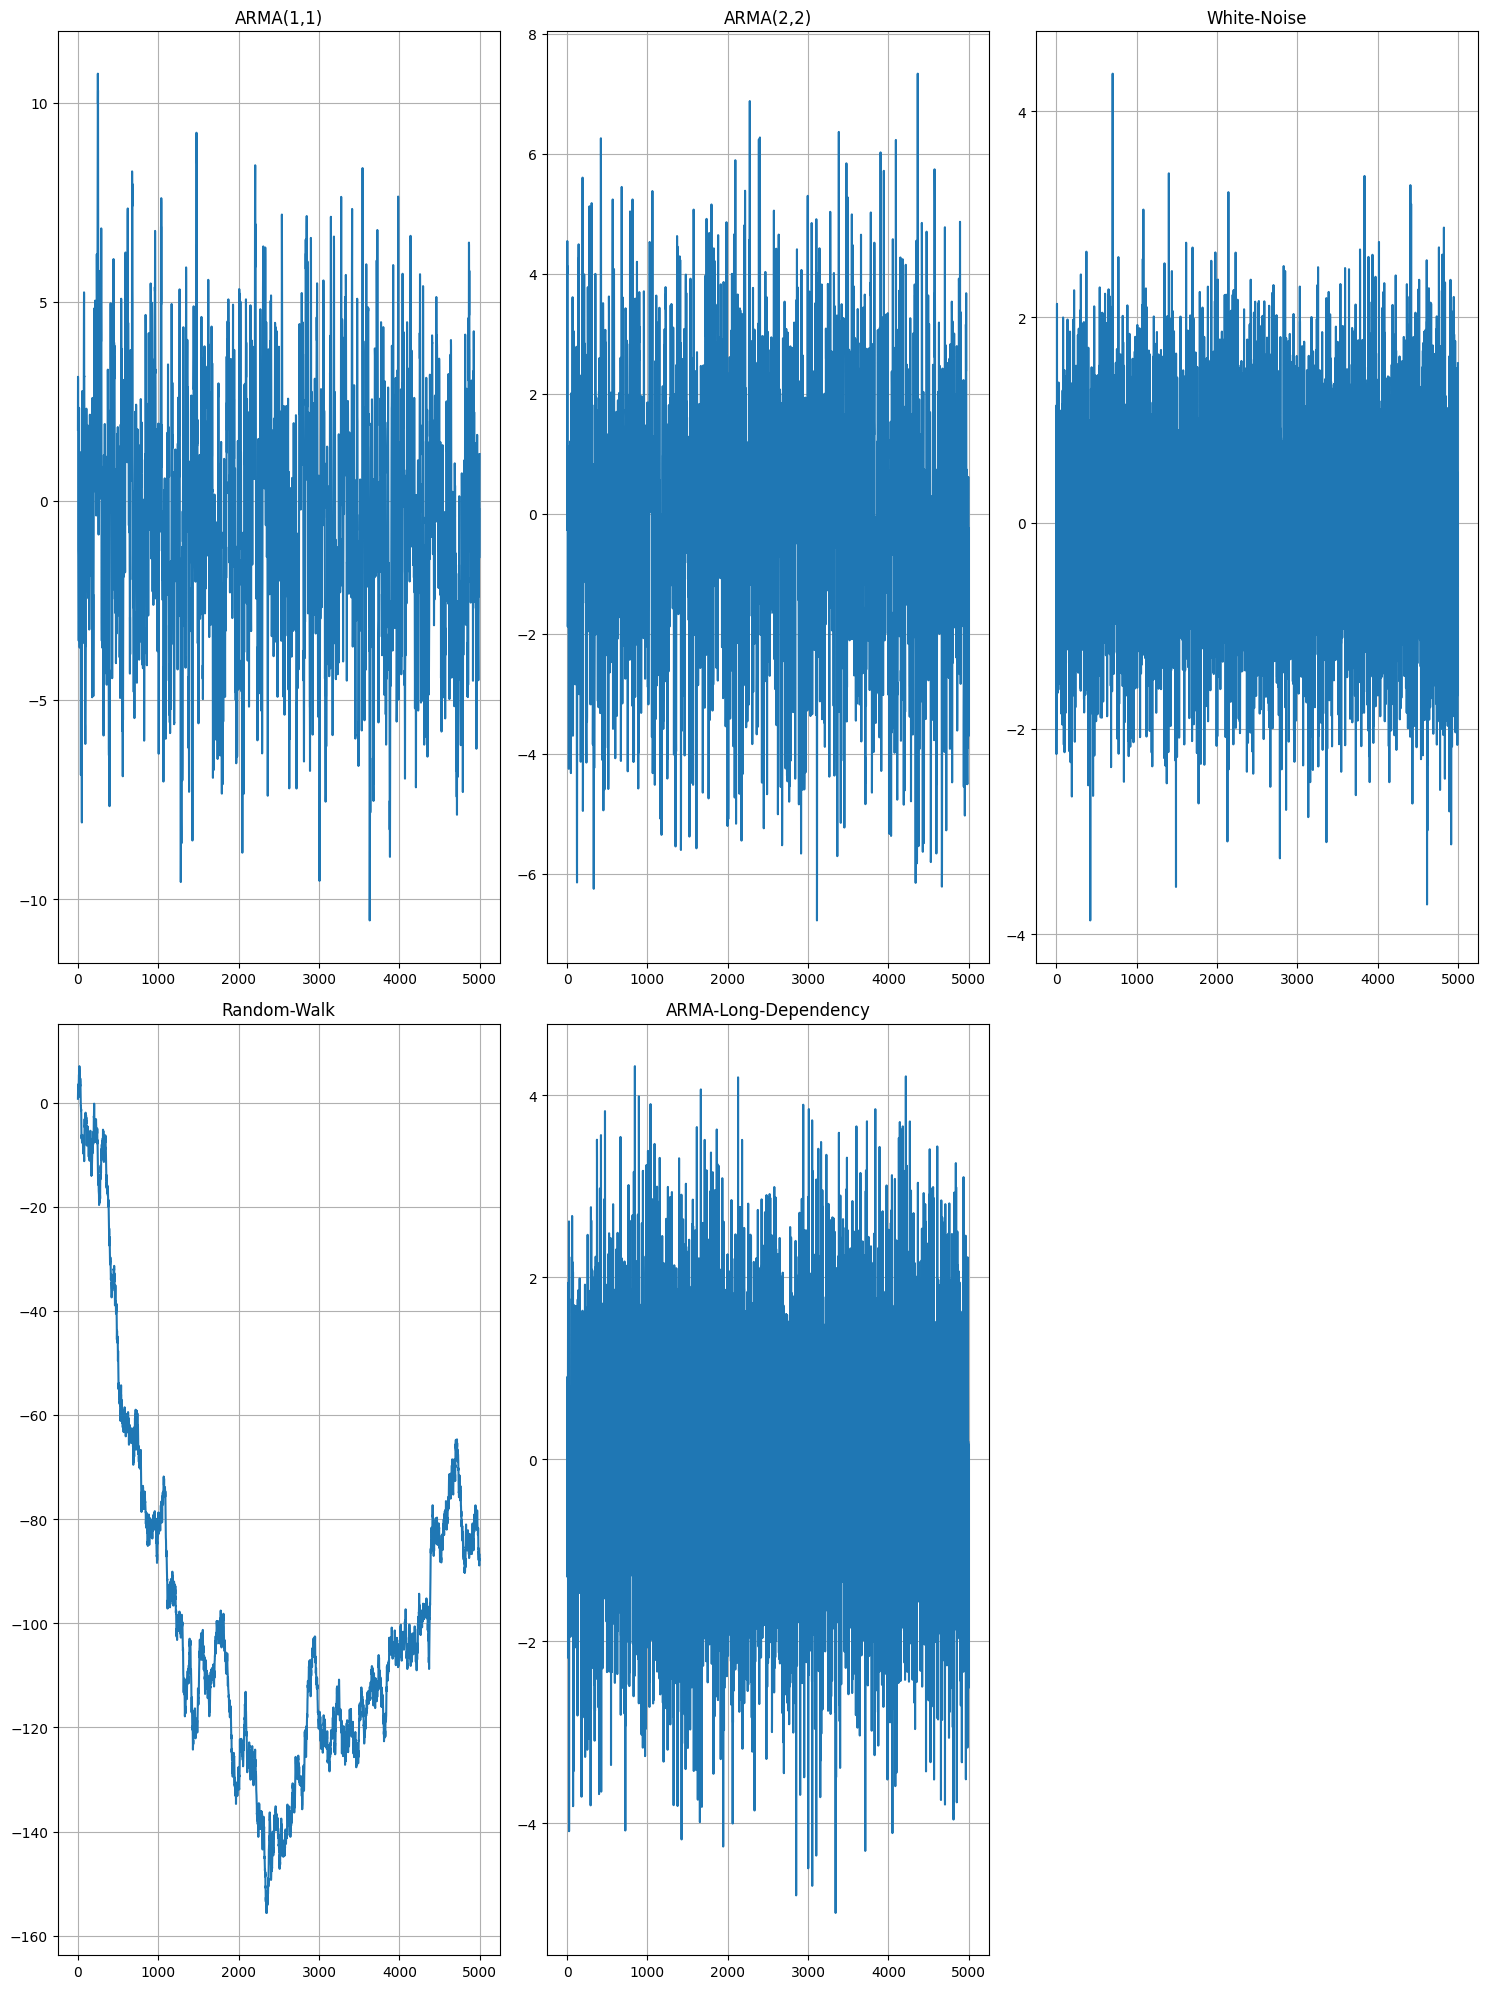

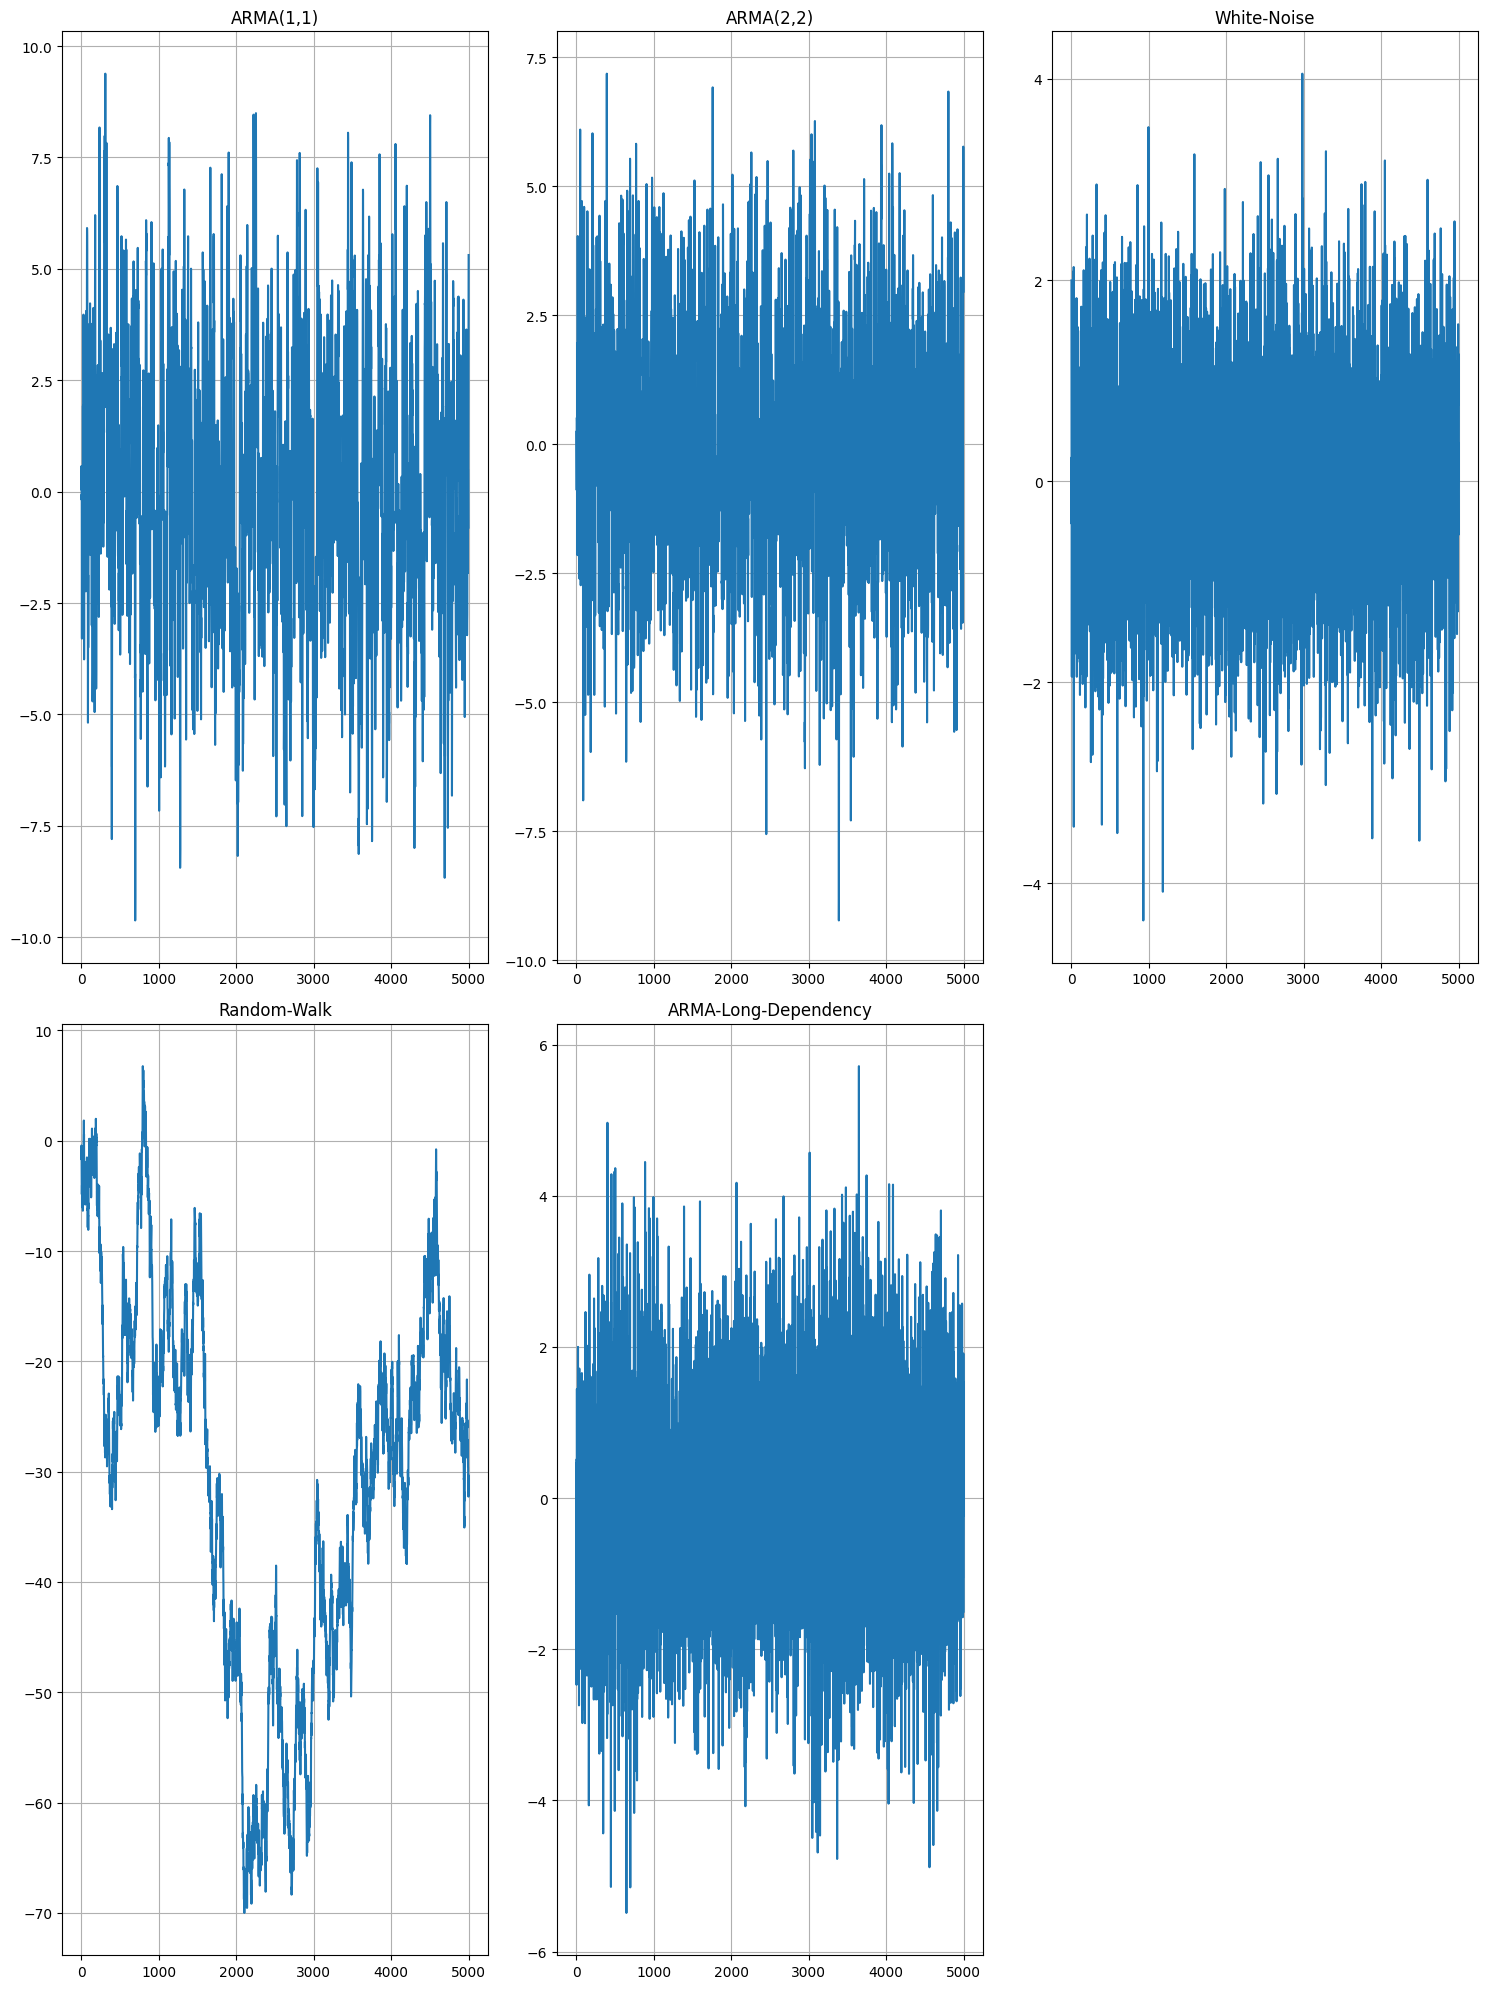

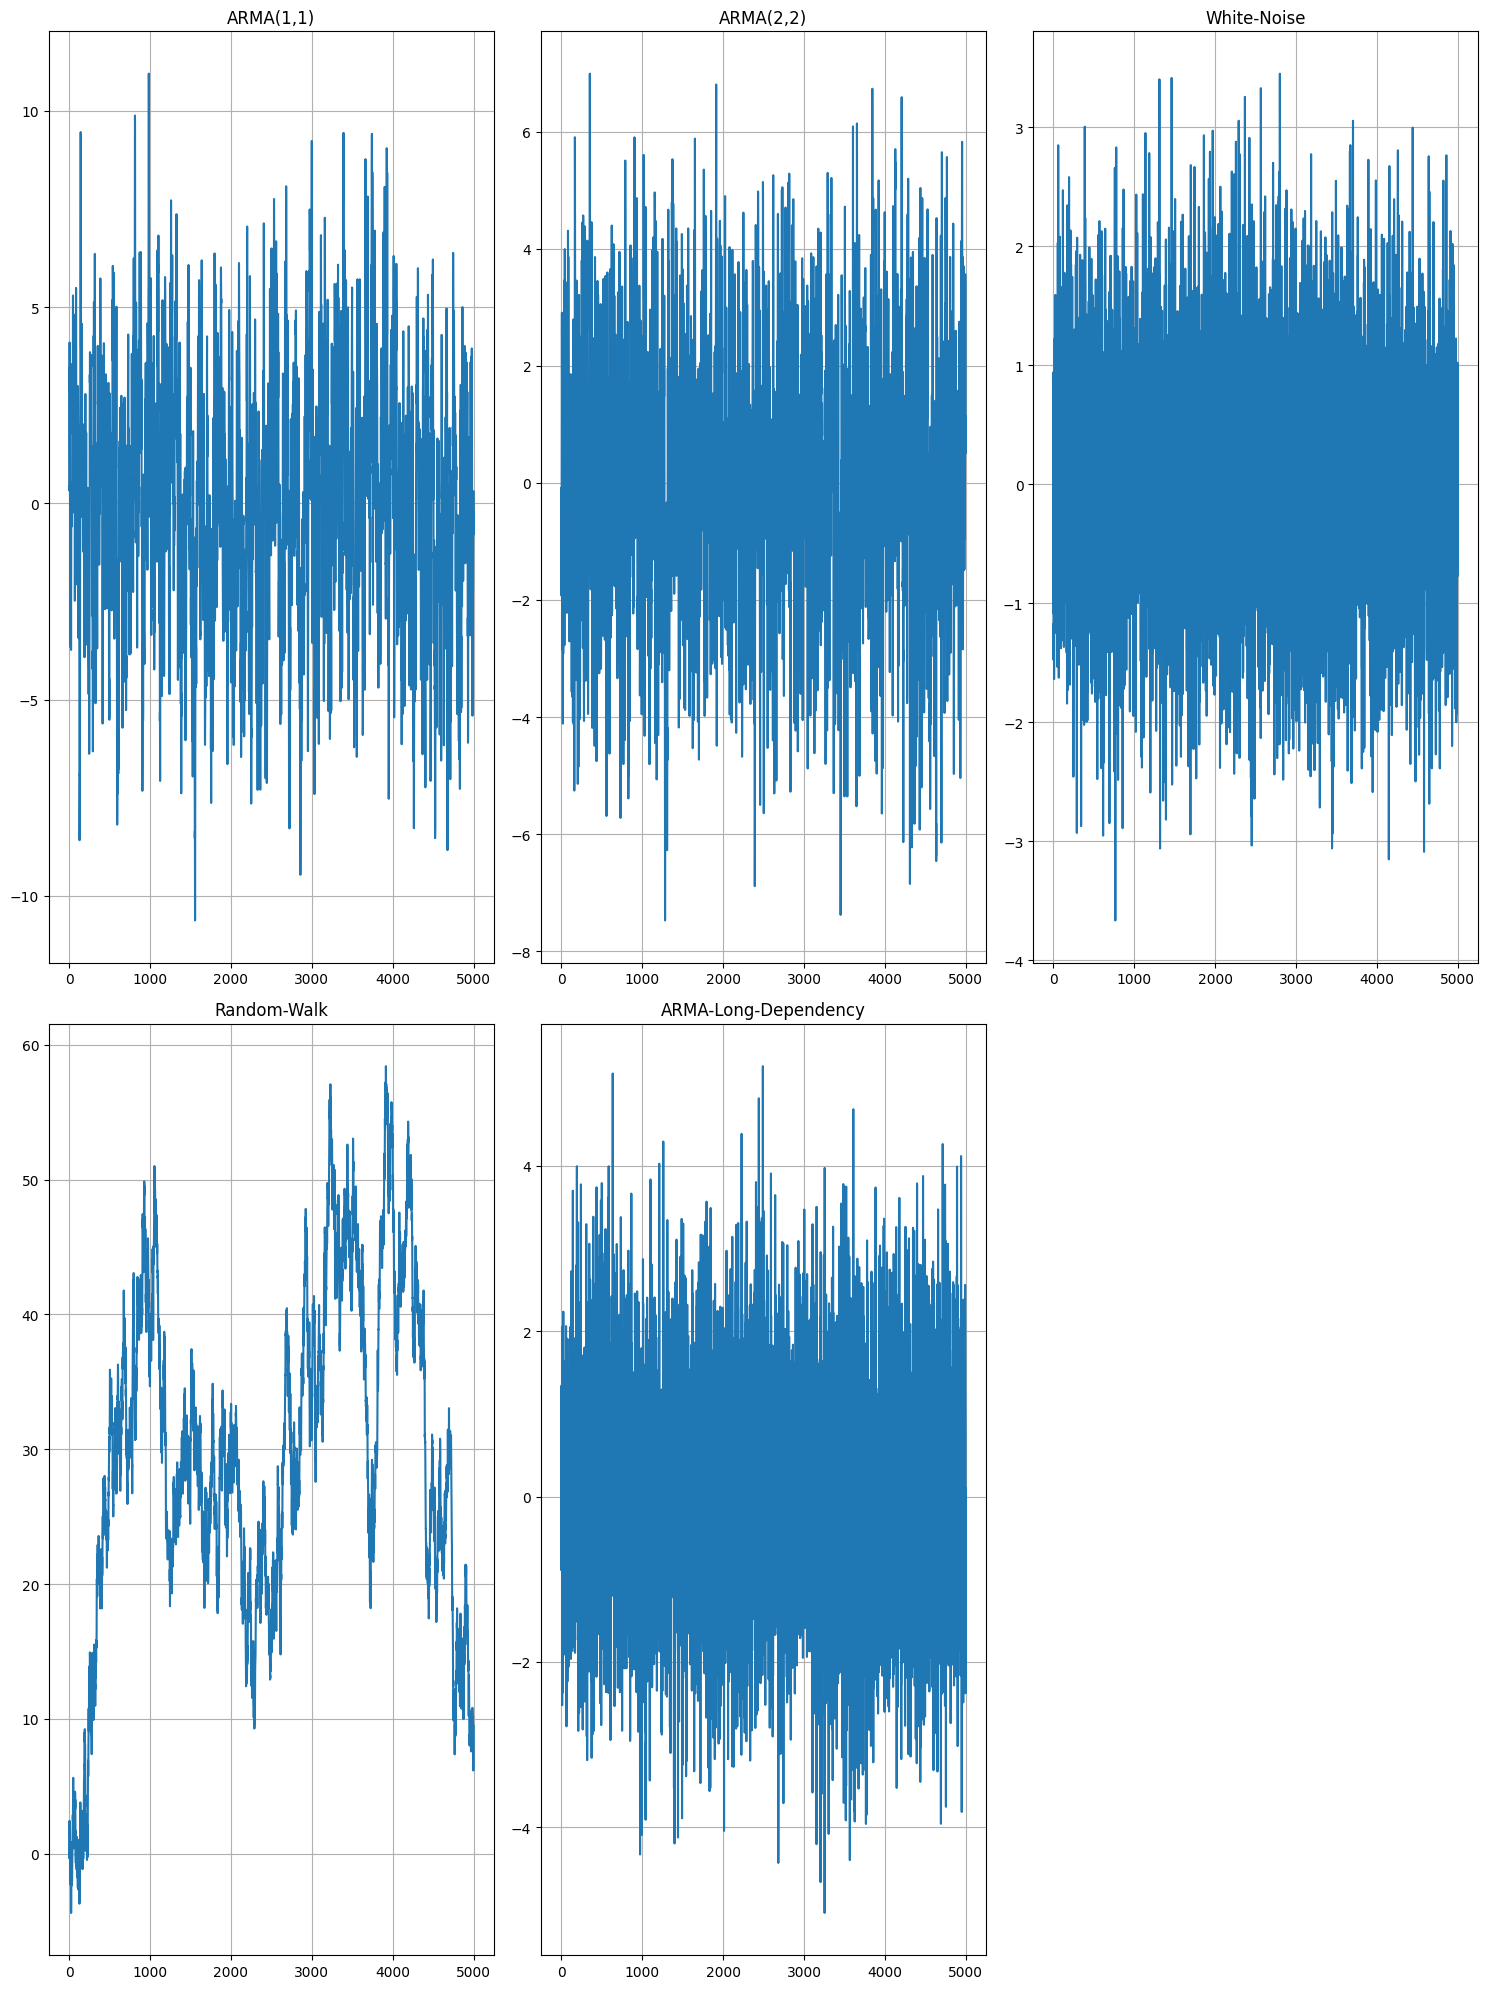

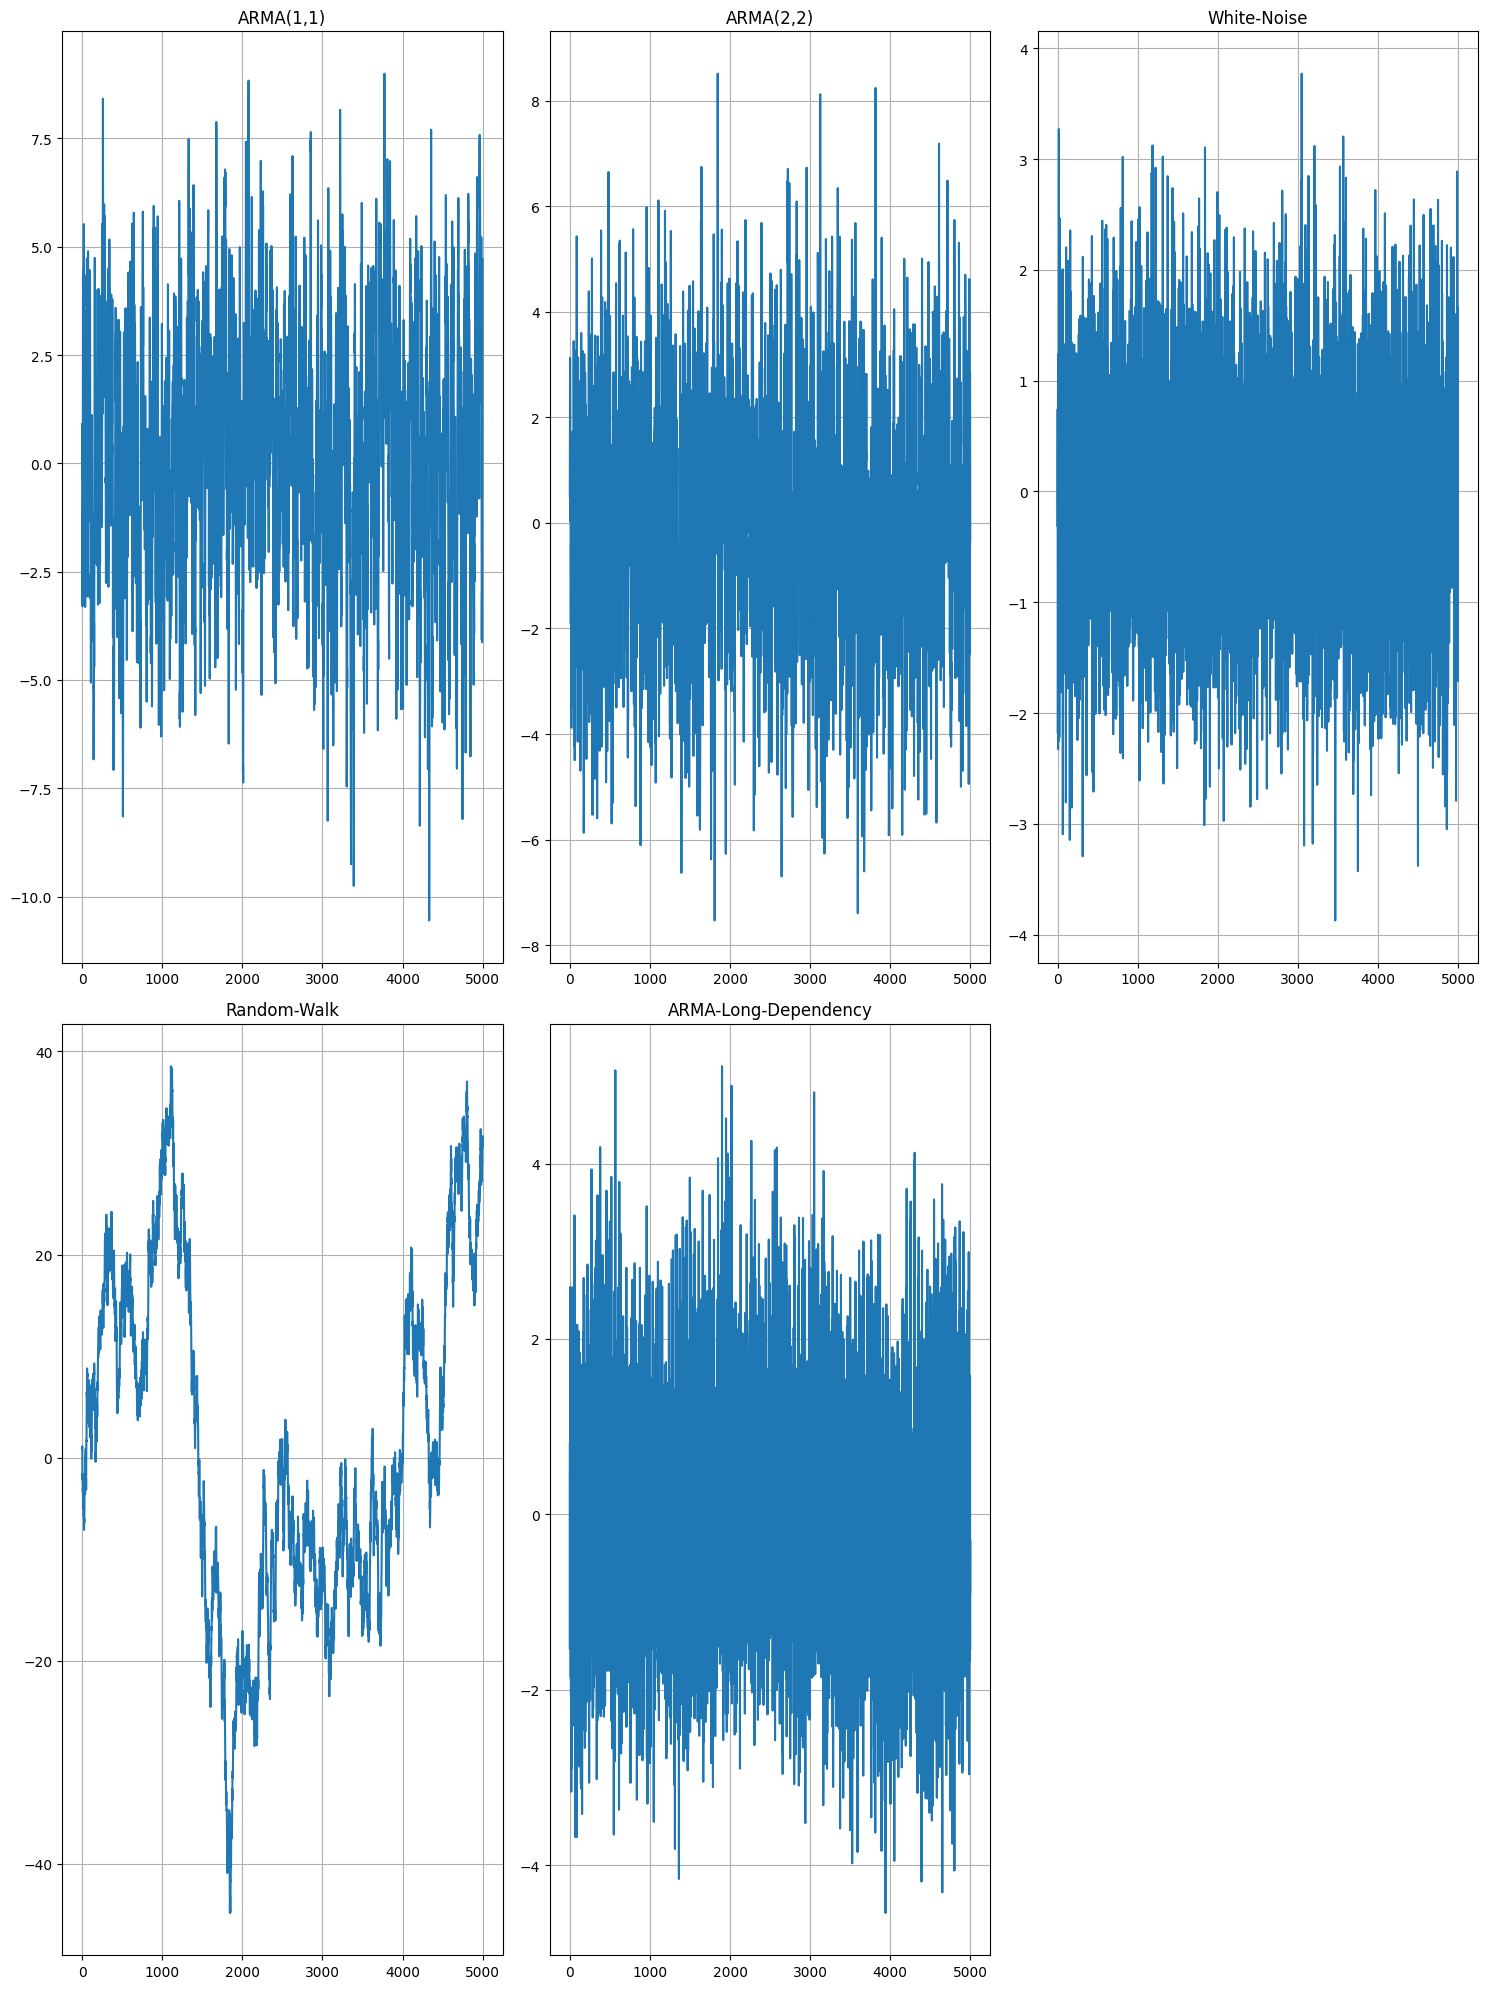

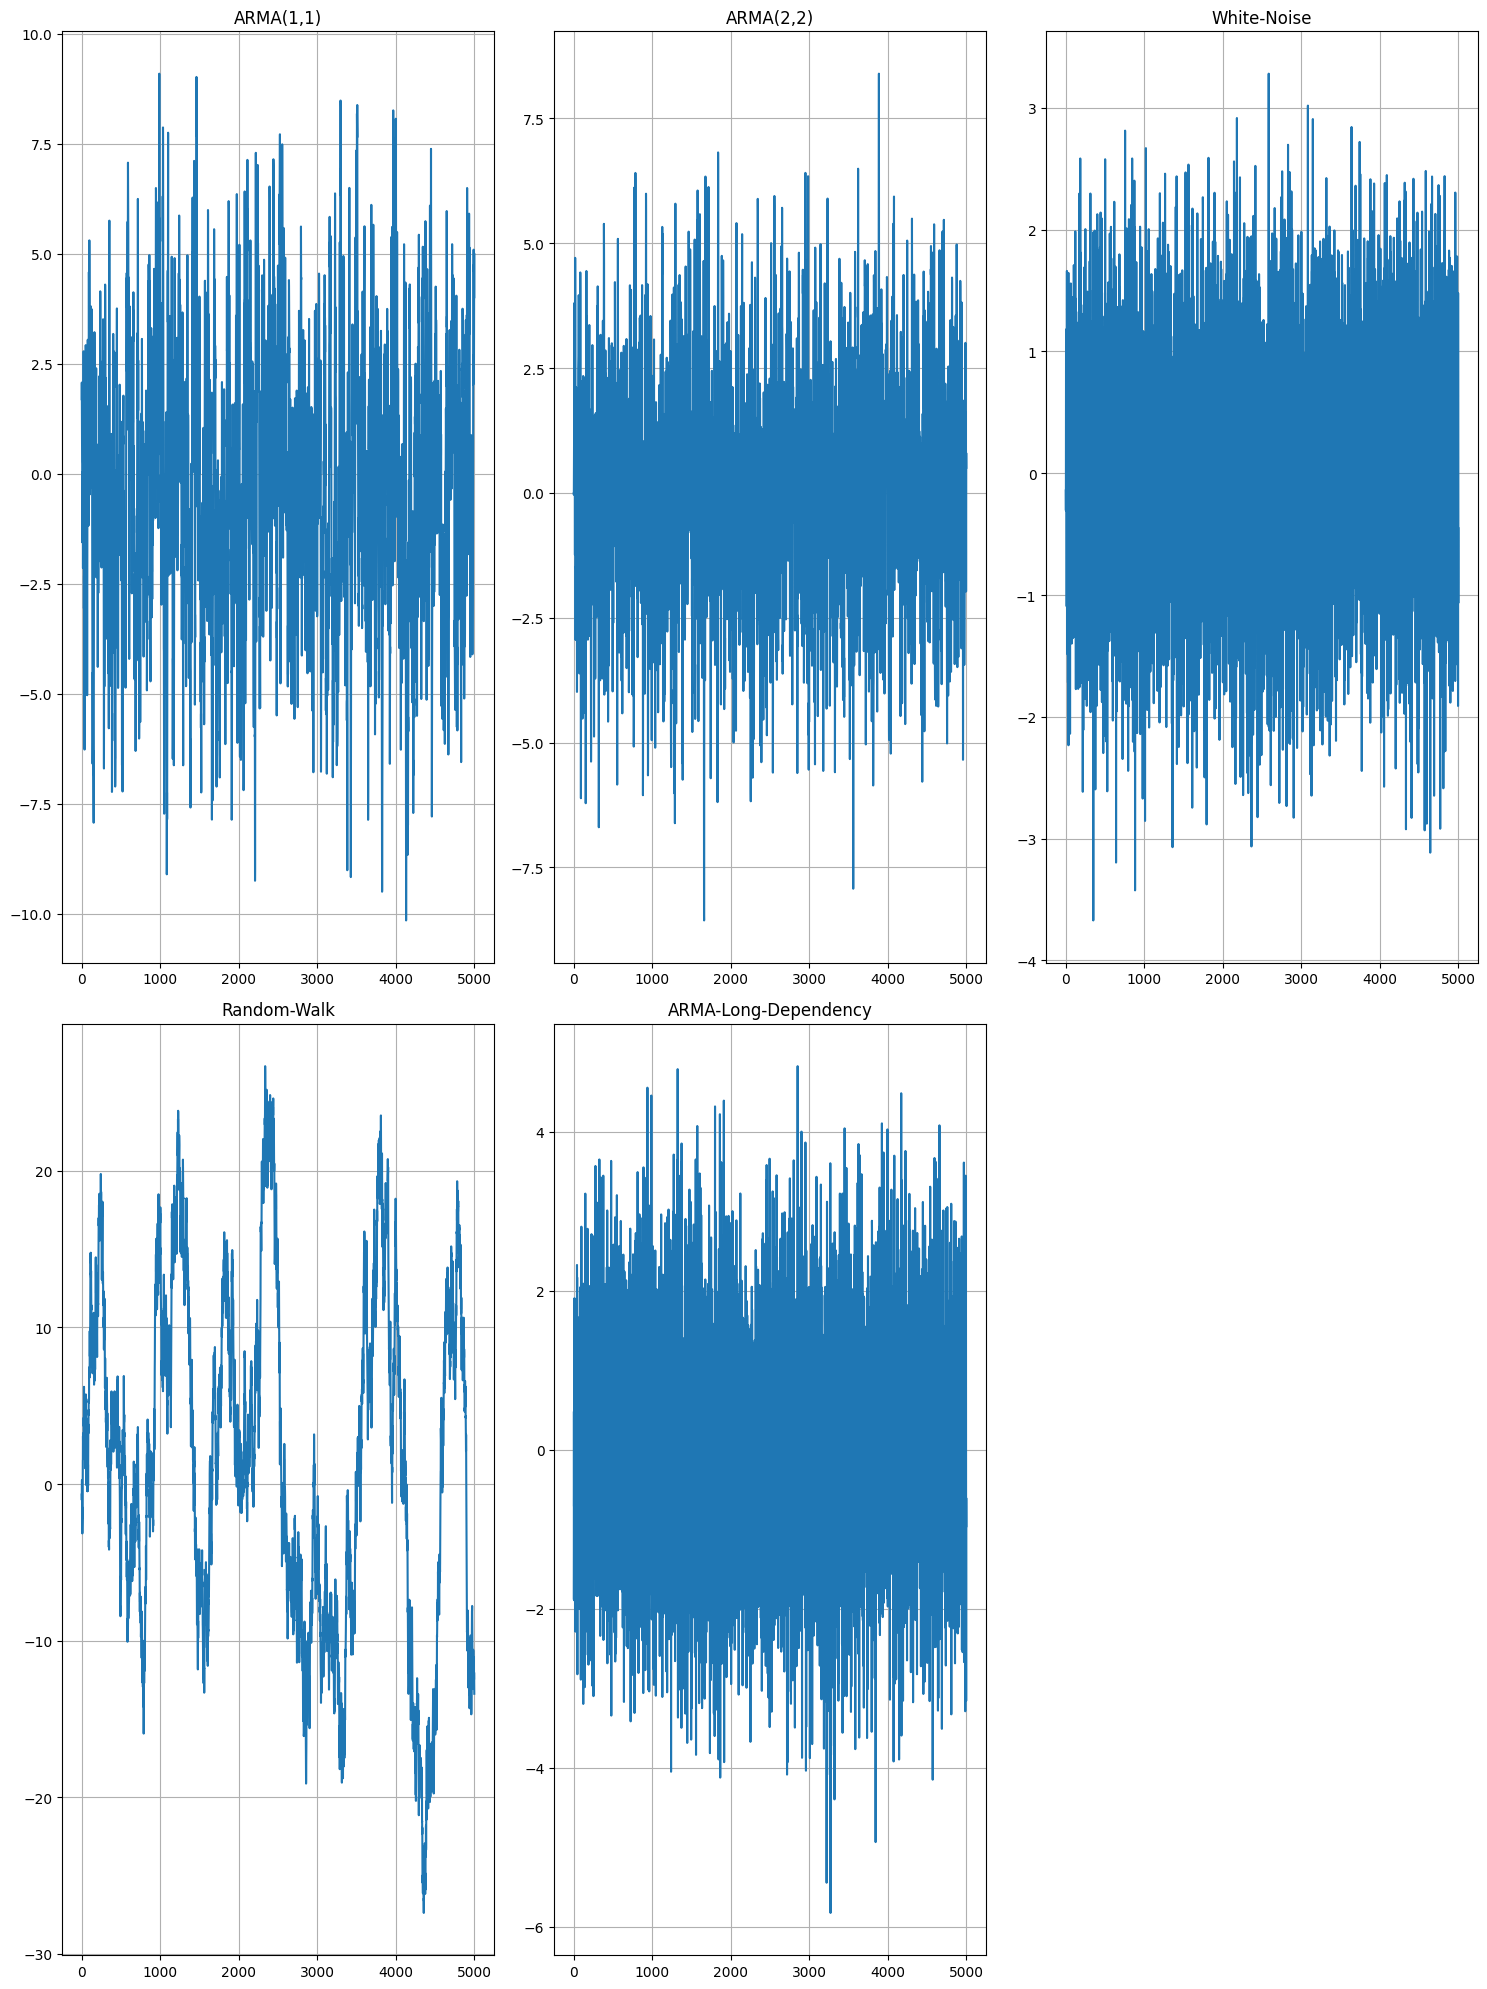

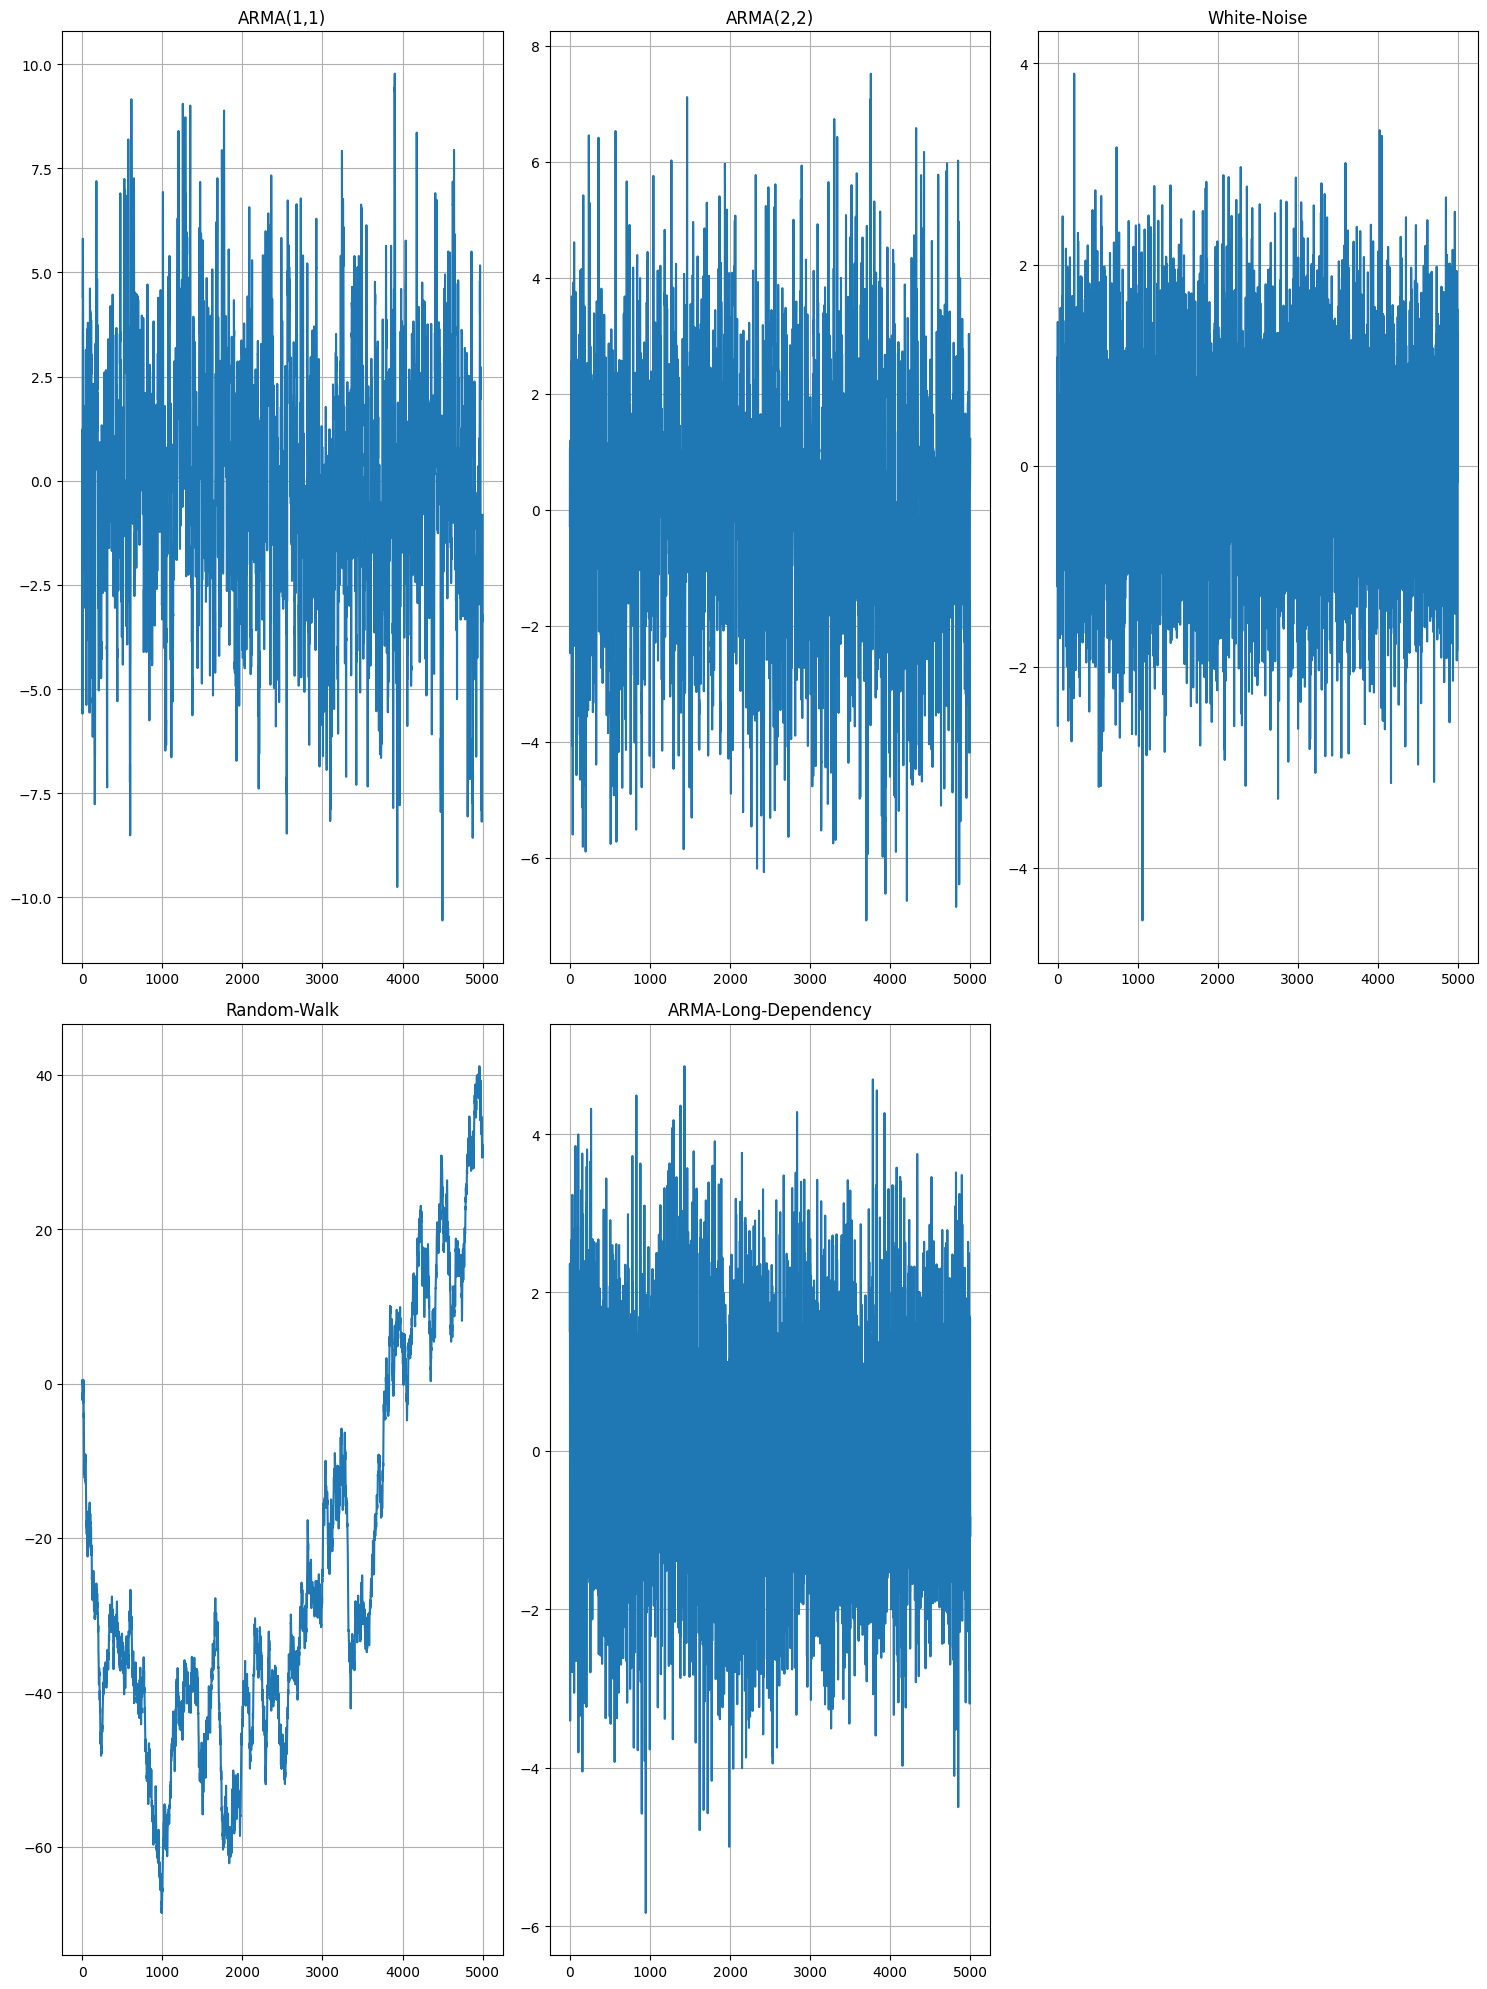

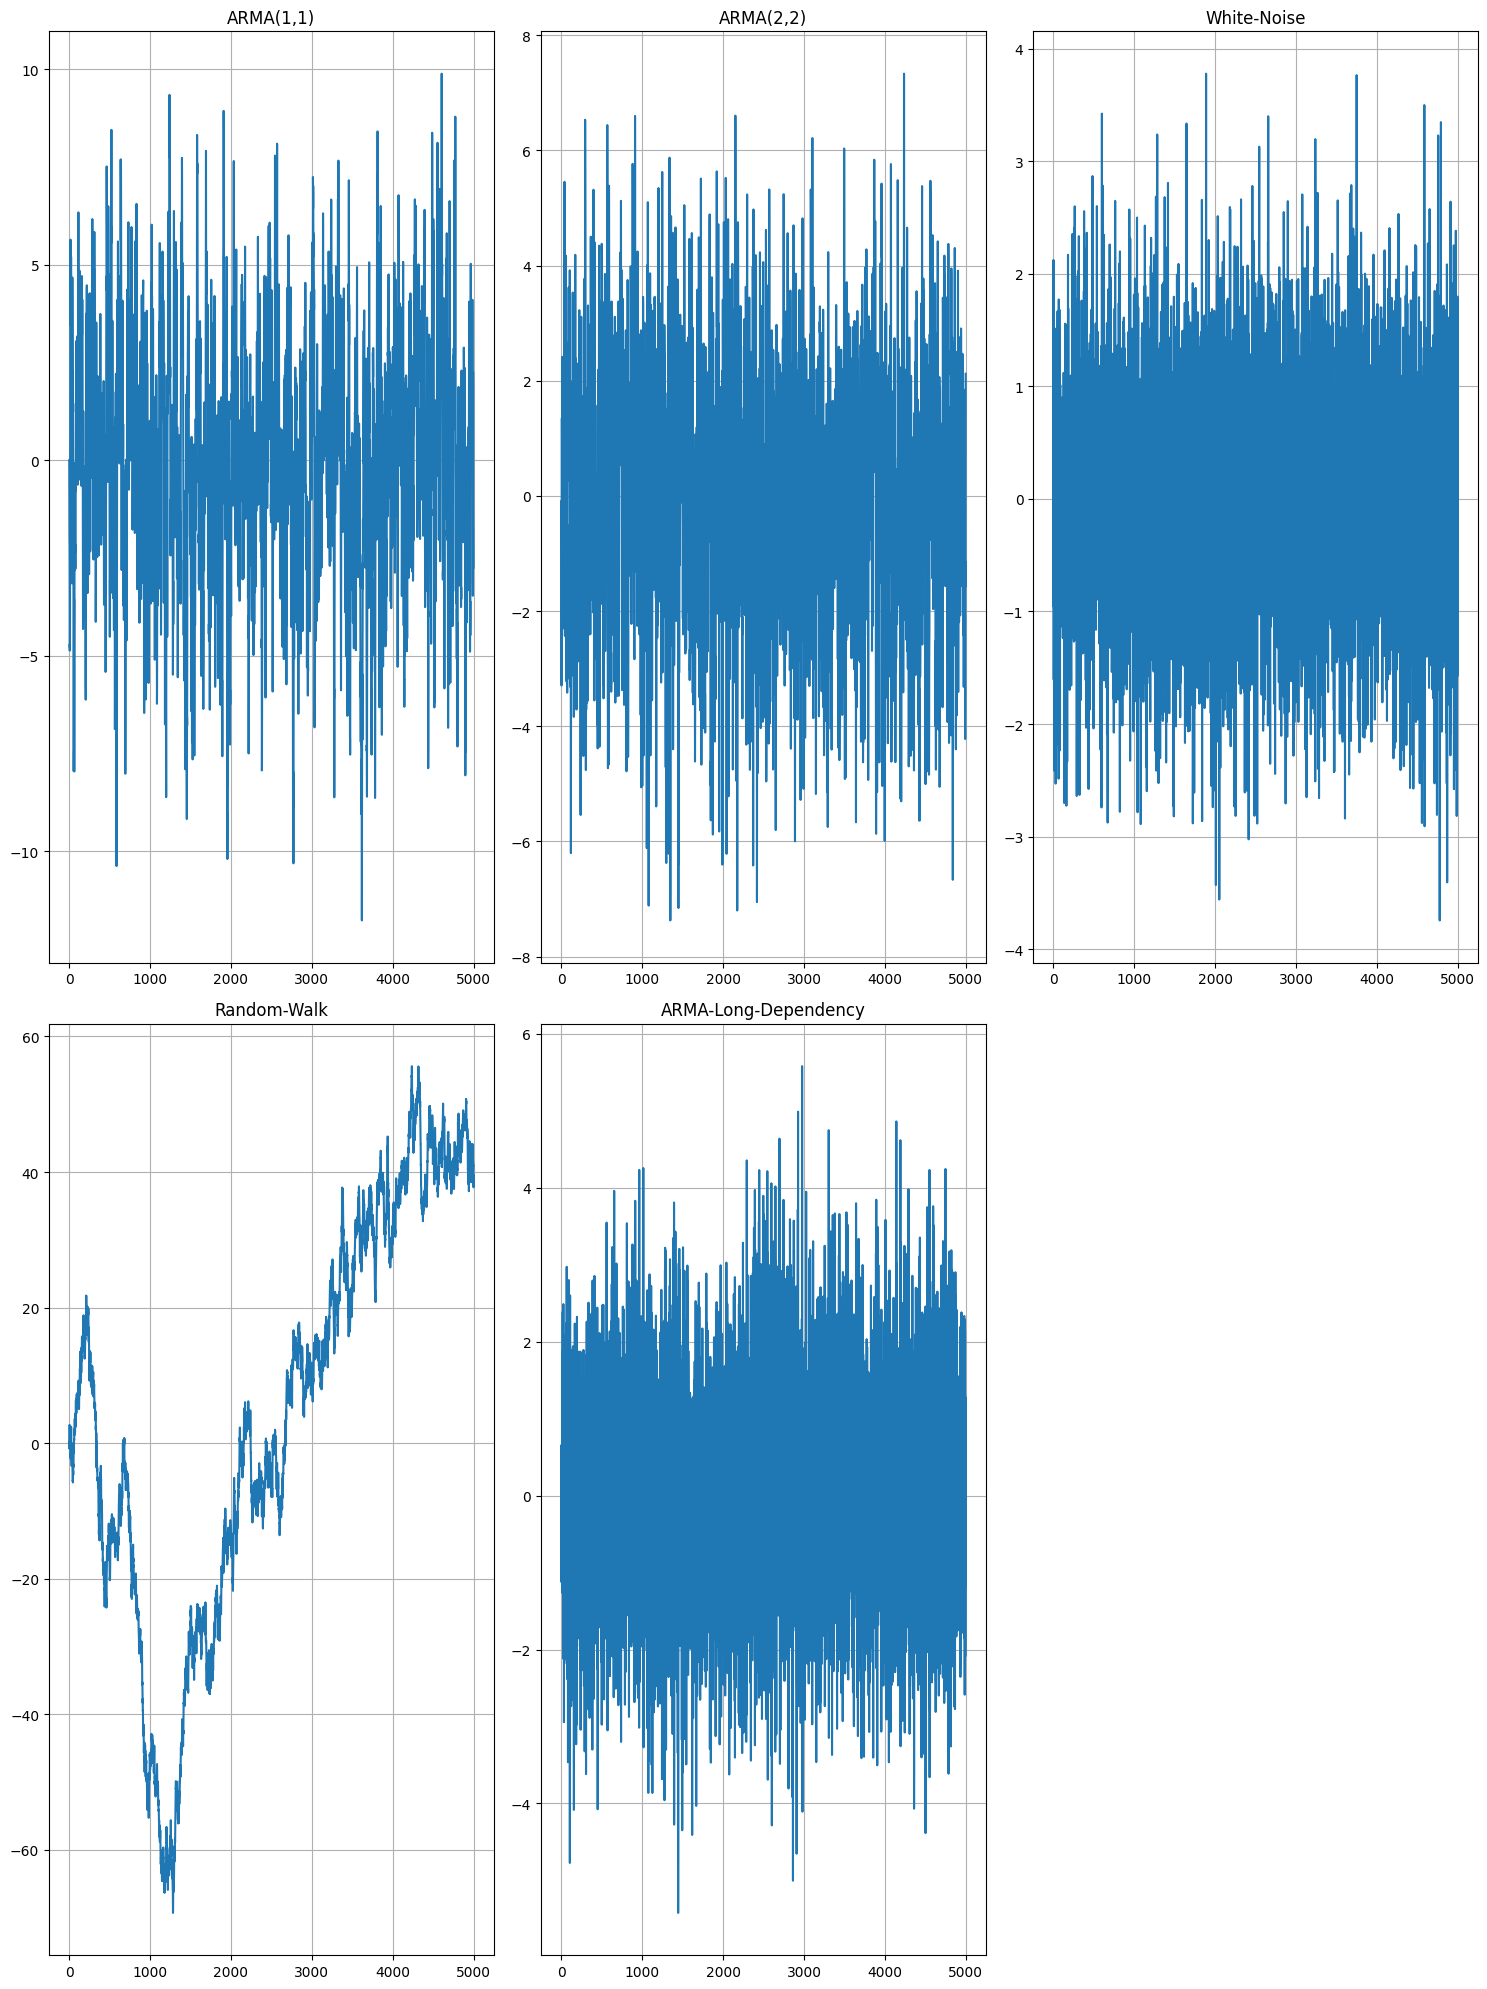

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from statsmodels.tsa.arima_process import ArmaProcess
import pandas as pd

def generate_long_dependency_arma(n, lag=50, ar_coef=0.7, ma_params=None):
    """
    Generate an ARMA process with long-term dependency where only the specified lag
    has a non-zero coefficient, creating a time series that depends only on values
    'lag' time steps in the past.
    
    Parameters:
    n (int): Length of the signal
    lag (int): The specific lag with non-zero coefficient (default=50)
    ar_coef (float): Coefficient value for the lag (abs value must be < 1 for stationarity)
    ma_params (list): Optional MA parameters (default=None)
    
    Returns:
    numpy.ndarray: Time series with the specified long-term dependency
    """
    # Create an array with zeros for all AR coefficients except at position 'lag'
    ar_params = np.zeros(lag)
    ar_params[lag-1] = ar_coef  # -1 because Python uses 0-based indexing
    
    # Default MA parameters if none provided
    if ma_params is None:
        ma_params = [0]
    
    # Generate the ARMA process - need to handle the statsmodels AR parameter format
    arma_process = ArmaProcess(ar=np.r_[1, -ar_params], ma=np.r_[1, np.array(ma_params)])
    
    # Generate longer signal to allow burn-in period for the dependencies to manifest
    extended_n = n + lag * 2
    signal = arma_process.generate_sample(nsample=extended_n)
    
    # Return only the latter portion after burn-in
    return signal[lag*2:]

# Shared helper functions for signal generation/noise utilities
try:
    from dataset.signal_generators import *
except ModuleNotFoundError:
    from signal_generators import *

# Dataset generation functions
def generate_and_save_datasets(seed, dataset_folder, dataset_id):
    """Generate and save time series datasets with long-term dependencies"""
    n = 5000  # Signal length
    np.random.seed(seed)  # Set random seed

    signal_generators = {
        "ARMA(1,1)": lambda: generate_arma_signal(n, ar_params=[0.85], ma_params=[0.65]),
        "ARMA(2,2)": lambda: generate_arma_signal(n, ar_params=[0.75, -0.2], ma_params=[0.65, 0.35]),
        "White-Noise": lambda: generate_white_noise(n),
        "Random-Walk": lambda: generate_random_walk(n),
        "ARMA-Long-Dependency": lambda: generate_long_dependency_arma(n, lag=50, ar_coef=0.7),
    }

    # Generate raw datasets and save
    signal_data_dict = {}
    for signal_name, generator in signal_generators.items():
        signal_data = generator()
        signal_data_dict[signal_name] = signal_data
        save_signal(signal_data, dataset_folder, signal_name, dataset_id=dataset_id, category="raw", length=n)

    # Visualize raw signals
    plot_signals(signal_data_dict)

def generate_multiple_datasets(num_datasets=5):
    """Generate multiple datasets with different random seeds"""
    output_folder = "Dataset_generated_autocorrelation-long-dependency"  
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    
    for i in range(num_datasets):
        seed = i
        generate_and_save_datasets(seed, output_folder, i+1)

if __name__ == "__main__":
    generate_multiple_datasets(num_datasets=10)